# Superdense Coding with Qiskit

In [112]:
import math
from pandas import DataFrame as df
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator

In [113]:
from qiskit.visualization import array_to_latex
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

In [124]:
def create_bell_pair(qc,a,b):
    qc.h(a)
    qc.cx(a,b)

In [130]:
def encode_message(qc,qubit,msg):
    if msg == "00":
        pass
    elif msg == "10": # following the Qiskit system  10 --> |01> 
        qc.x(qubit)
    elif msg == "01": 
        qc.z(qubit)
    elif msg == "11":
        qc.z(qubit)
        qc.x(qubit)
    else:
        print("Invalid Message: Sending '00'")

In [131]:
def decode_message(qc,a,b):
    qc.cx(a,b)
    qc.h(a)

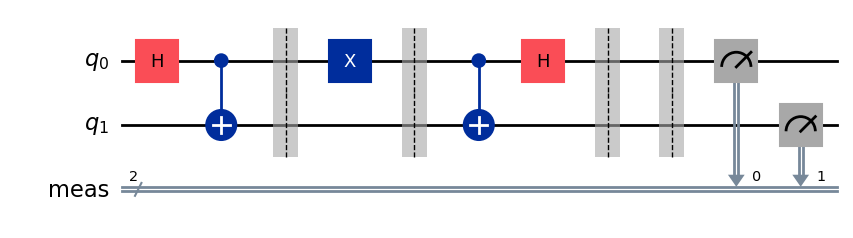

In [140]:
qc = QuantumCircuit(2, name ="qc")

create_bell_pair(qc,0,1)
qc.barrier()
encode_message(qc,0,"10")
qc.barrier()
decode_message(qc,0,1)
qc.barrier()

qc.measure_all()
qc.draw("mpl")


Total Counts are: {'10': 1000}


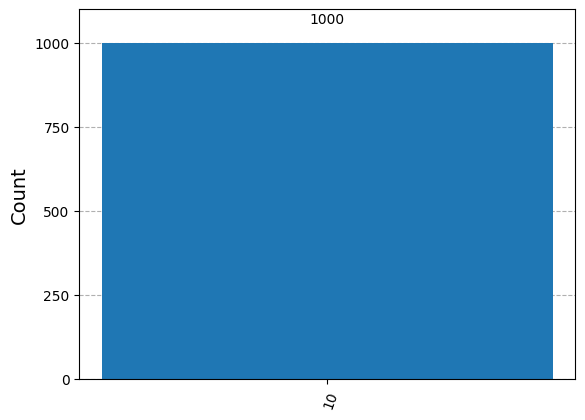

In [141]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)